In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pathlib import Path

DATASET_DIR = Path('../learn_dataset_narrow_angle_fixed')
OUT_DIR     = Path('.')
VE_PEAK_OFFSET = 5

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

In [19]:
# gen_rd_maps.ipynb と同じ sample 73 を使用
SAMPLE_ID = 43
VMAX, VMIN = 0.0, -40.0

d = np.load(DATASET_DIR / f'sample_{SAMPLE_ID:05d}.npz', allow_pickle=True)
rd_maps      = d['rd_maps']       # (10, 89, 190) complex64
fixed_angles = d['fixed_angles']  # (10,)
cy_d = int(d['cyclist_true_d_idx'])
cy_r = int(d['cyclist_true_r_idx'])
ve_d = int(d['vehicle_true_d_idx'])
ve_r = int(d['vehicle_true_r_idx'])
ve_r_peak = ve_r - VE_PEAK_OFFSET
cy_ang = float(d['cyclist_true_angle_deg'])
ve_ang = float(d['vehicle_true_angle_deg'])

print(f'Cyclist: d={cy_d}, r={cy_r}, angle={cy_ang:.2f}°')
print(f'Vehicle: d={ve_d}, r={ve_r}, peak≈{ve_r_peak}, angle={ve_ang:.2f}°')

ch_mid = int(np.argmin(np.abs(fixed_angles - (cy_ang + ve_ang) / 2)))
print(f'表示チャネル: [{ch_mid}] {fixed_angles[ch_mid]:.2f}°')

rd_linear = np.abs(rd_maps[ch_mid]).astype(np.float32)  # (89, 190)
rd_db     = 20 * np.log10(np.maximum(rd_linear, 1e-12))

R_C = (cy_r + ve_r_peak) // 2
R_LO, R_HI = max(0, R_C - 30), min(189, R_C + 30)
D_LO, D_HI = 0, 8

Cyclist: d=1, r=118, angle=3.29°
Vehicle: d=1, r=127, peak≈122, angle=1.66°
表示チャネル: [4] 2.33°


In [ ]:
def cfar2d(rd_linear, n_train_d, n_guard_d, n_train_r, n_guard_r, pfa):
    """2D CA-CFAR を適用し、検出マスク (H, W) を返す。"""
    kd = 2 * (n_train_d + n_guard_d) + 1
    kr = 2 * (n_train_r + n_guard_r) + 1
    kernel = torch.ones((1, 1, kd, kr))
    kernel[:, :, n_train_d : n_train_d + 2*n_guard_d + 1,
                 n_train_r : n_train_r + 2*n_guard_r + 1] = 0
    n_train_cells = int(kernel.sum().item())

    alpha = n_train_cells * (pfa ** (-1.0 / n_train_cells) - 1.0)

    pad_r = n_train_r + n_guard_r
    pad_d = n_train_d + n_guard_d

    x = torch.from_numpy(rd_linear).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
    # 4D tensor には padding size=4 が必要: (left_W, right_W, top_H, bottom_H)
    x_pad = F.pad(x,     (pad_r, pad_r, 0, 0),       mode='replicate')  # range 方向
    x_pad = F.pad(x_pad, (0, 0, pad_d, pad_d),        mode='circular')   # Doppler 方向
    noise_est = (F.conv2d(x_pad, kernel) / n_train_cells)[0, 0].numpy()

    mask = rd_linear > alpha * noise_est
    return mask, alpha, n_train_cells


N_TRAIN_D, N_GUARD_D = 3, 1
N_TRAIN_R, N_GUARD_R = 5, 2

PFA_HIGH = 1e-6
PFA_LOW  = 1e-2

mask_high, alpha_high, n_cells = cfar2d(rd_linear, N_TRAIN_D, N_GUARD_D, N_TRAIN_R, N_GUARD_R, PFA_HIGH)
mask_low,  alpha_low,  _      = cfar2d(rd_linear, N_TRAIN_D, N_GUARD_D, N_TRAIN_R, N_GUARD_R, PFA_LOW)

print(f'n_train_cells={n_cells}')
print(f'PFA={PFA_HIGH:.0e}: alpha={alpha_high:.2f},  検出セル数={mask_high.sum()}')
print(f'PFA={PFA_LOW:.0e}:  alpha={alpha_low:.2f},   検出セル数={mask_low.sum()}')

n_train_cells=120
PFA=1e-06: alpha=14.64,  検出セル数=12
PFA=1e-01:  alpha=2.32,   検出セル数=413


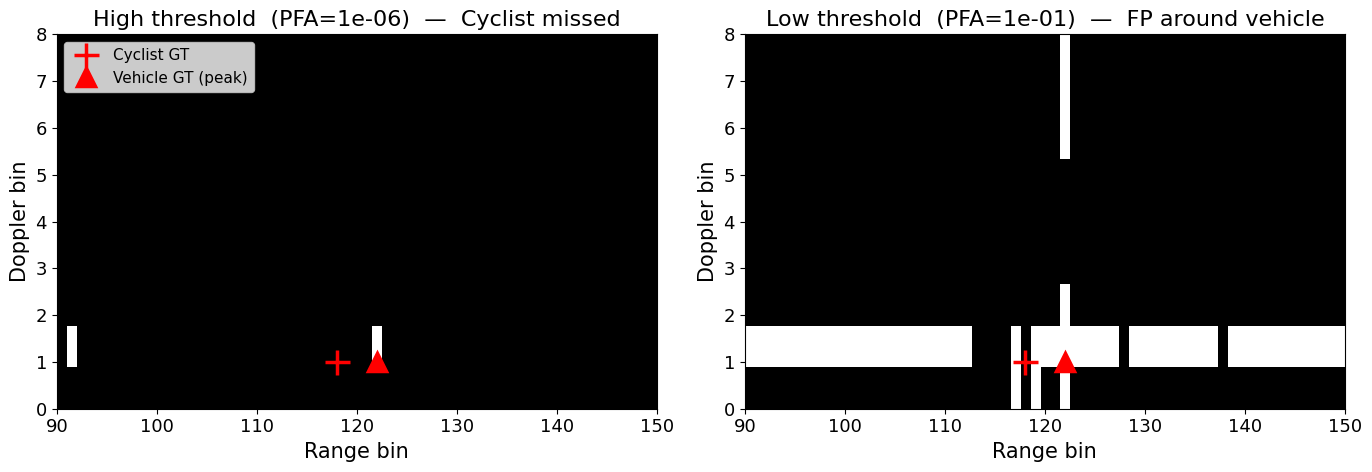

saved → cfar_failure_00043.png


In [43]:
# ── CFAR 失敗モードの可視化 ──────────────────────────────────────────────
# 左: 高閾値 → 自転車見落とし
# 右: 低閾値 → 自転車は拾えるが自動車周りに FP 多発
# 検出結果はビン単位の白/黒（検出=白, 非検出=黒）で表示

def plot_cfar_binary(ax, mask, cy_d, cy_r, ve_d, ve_r_peak,
                     r_lo, r_hi, d_lo, d_hi, title):
    """検出マスクを白黒 2 値画像で表示し、GT 位置にマーカーを打つ。"""
    binary = mask[d_lo:d_hi+1, r_lo:r_hi+1].astype(np.float32)  # 0=黒, 1=白
    ax.imshow(
        binary,
        aspect='auto', origin='lower', cmap='gray',
        vmin=0, vmax=1,
        extent=[r_lo, r_hi, d_lo, d_hi],
    )
    ax.plot(cy_r,      cy_d, 'r+', markersize=18, markeredgewidth=2.5,
            label='Cyclist GT', zorder=4)
    ax.plot(ve_r_peak, ve_d, 'r^', markersize=13, markeredgewidth=2.5,
            label='Vehicle GT (peak)', zorder=4)
    ax.set_xlabel('Range bin')
    ax.set_ylabel('Doppler bin')
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_cfar_binary(
    axes[0], mask_high, cy_d, cy_r, ve_d, ve_r_peak,
    R_LO, R_HI, D_LO, D_HI,
    title=f'High threshold  (PFA={PFA_HIGH:.0e})  —  Cyclist missed',
)
plot_cfar_binary(
    axes[1], mask_low, cy_d, cy_r, ve_d, ve_r_peak,
    R_LO, R_HI, D_LO, D_HI,
    title=f'Low threshold  (PFA={PFA_LOW:.0e})  —  FP around vehicle',
)

axes[0].legend(fontsize=11, loc='upper left')
plt.tight_layout()
out = OUT_DIR / f'cfar_failure_{SAMPLE_ID:05d}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'saved → {out}')

In [22]:
# ── PFA チューニング補助: GT 付近の検出状況を確認 ───────────────────────
# うまく失敗モードが出ない場合はここで PFA_HIGH / PFA_LOW を調整する

R_TOL, D_TOL = 3, 2   # GT との一致判定トレランス

def check_detection(mask, cy_d, cy_r, ve_d, ve_r_peak, label):
    cy_hit = bool(mask[max(0,cy_d-D_TOL):cy_d+D_TOL+1,
                       max(0,cy_r-R_TOL):cy_r+R_TOL+1].any())
    ve_hit = bool(mask[max(0,ve_d-D_TOL):ve_d+D_TOL+1,
                       max(0,ve_r_peak-R_TOL):ve_r_peak+R_TOL+1].any())
    fp_total = int(mask.sum())
    print(f'{label}: cyclist={"HIT" if cy_hit else "MISS"},'
          f' vehicle={"HIT" if ve_hit else "MISS"},'
          f' total_det={fp_total}')

check_detection(mask_high, cy_d, cy_r, ve_d, ve_r_peak, f'PFA={PFA_HIGH:.0e}')
check_detection(mask_low,  cy_d, cy_r, ve_d, ve_r_peak, f'PFA={PFA_LOW:.0e} ')

PFA=1e-04: cyclist=MISS, vehicle=HIT, total_det=19
PFA=1e-01 : cyclist=HIT, vehicle=HIT, total_det=413
